# Lab 03-A: Computer Vision with Classical Machine Learning
## ITAI 1378 — Module 03 | Houston Community College


---

### Lab Overview
In this lab we build face-recognition models using the **Olivetti Faces** dataset and classical machine learning.  
We explore two feature descriptors — **HOG** (edge/gradient) and **LBP** (texture) — and two classifiers — **SVM** and **Random Forest**.  
The most important lesson: a model with **99 % training accuracy can be a disaster in production**.  
We will see exactly why overfitting happens and how to guard against it.

### Learning Objectives
1. Understand the complete classical ML pipeline for computer vision  
2. Extract and compare HOG and LBP features  
3. Implement SVM and Random Forest classifiers  
4. **Critically:** understand why 99 % training accuracy often means model failure  
5. Build models that generalise to unseen data  

### Sections
| Section | Topic | Points |
|---------|-------|--------|
| 1 | Environment Setup & Data Preparation | 15 |
| 2 | Feature Extraction Deep Dive | 25 |
| 3 | Classical ML Algorithms | 25 |
| 4 | The Training Trap — Overfitting | 25 |
| 5 | Final Model Selection & Evaluation | 10 |
| **Total** | | **100** |


---
## Section 1: Environment Setup & Data Preparation
### (15 points)

**Key Learning:** Proper data preparation and the critical importance of splitting data into  
train / validation / test sets *before* any model touches it.


In [1]:
# ── Cell 1-1: Install / import all required libraries ──────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# scikit-learn
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

# scikit-image feature extractors
from skimage.feature import hog, local_binary_pattern
from skimage import exposure

print("✅  All libraries imported successfully.")
print(f"   numpy  {np.__version__}")

import sklearn, skimage
print(f"   scikit-learn  {sklearn.__version__}")
print(f"   scikit-image  {skimage.__version__}")


✅  All libraries imported successfully.
   numpy  2.0.2
   scikit-learn  1.6.1
   scikit-image  0.25.2


In [2]:
# ── Cell 1-2: Load the Olivetti Faces dataset ──────────────────────────────────
faces_data = fetch_olivetti_faces(shuffle=True, random_state=42)

X = faces_data.images          # (400, 64, 64)  — raw pixel arrays
y = faces_data.target          # (400,)          — integer subject IDs 0-39
X_flat = faces_data.data       # (400, 4096)     — flattened pixels

print("=" * 55)
print("  OLIVETTI FACES DATASET — OVERVIEW")
print("=" * 55)
print(f"  Total images      : {X.shape[0]}")
print(f"  Image dimensions  : {X.shape[1]} x {X.shape[2]} pixels")
print(f"  Pixel range       : [{X.min():.3f}, {X.max():.3f}]  (float32)")
print(f"  Number of subjects: {len(np.unique(y))}")
print(f"  Images per subject: {X.shape[0] // len(np.unique(y))}")
print(f"  Flattened vector  : {X_flat.shape[1]} features/image")
print("=" * 55)


downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data
  OLIVETTI FACES DATASET — OVERVIEW
  Total images      : 400
  Image dimensions  : 64 x 64 pixels
  Pixel range       : [0.000, 1.000]  (float32)
  Number of subjects: 40
  Images per subject: 10
  Flattened vector  : 4096 features/image


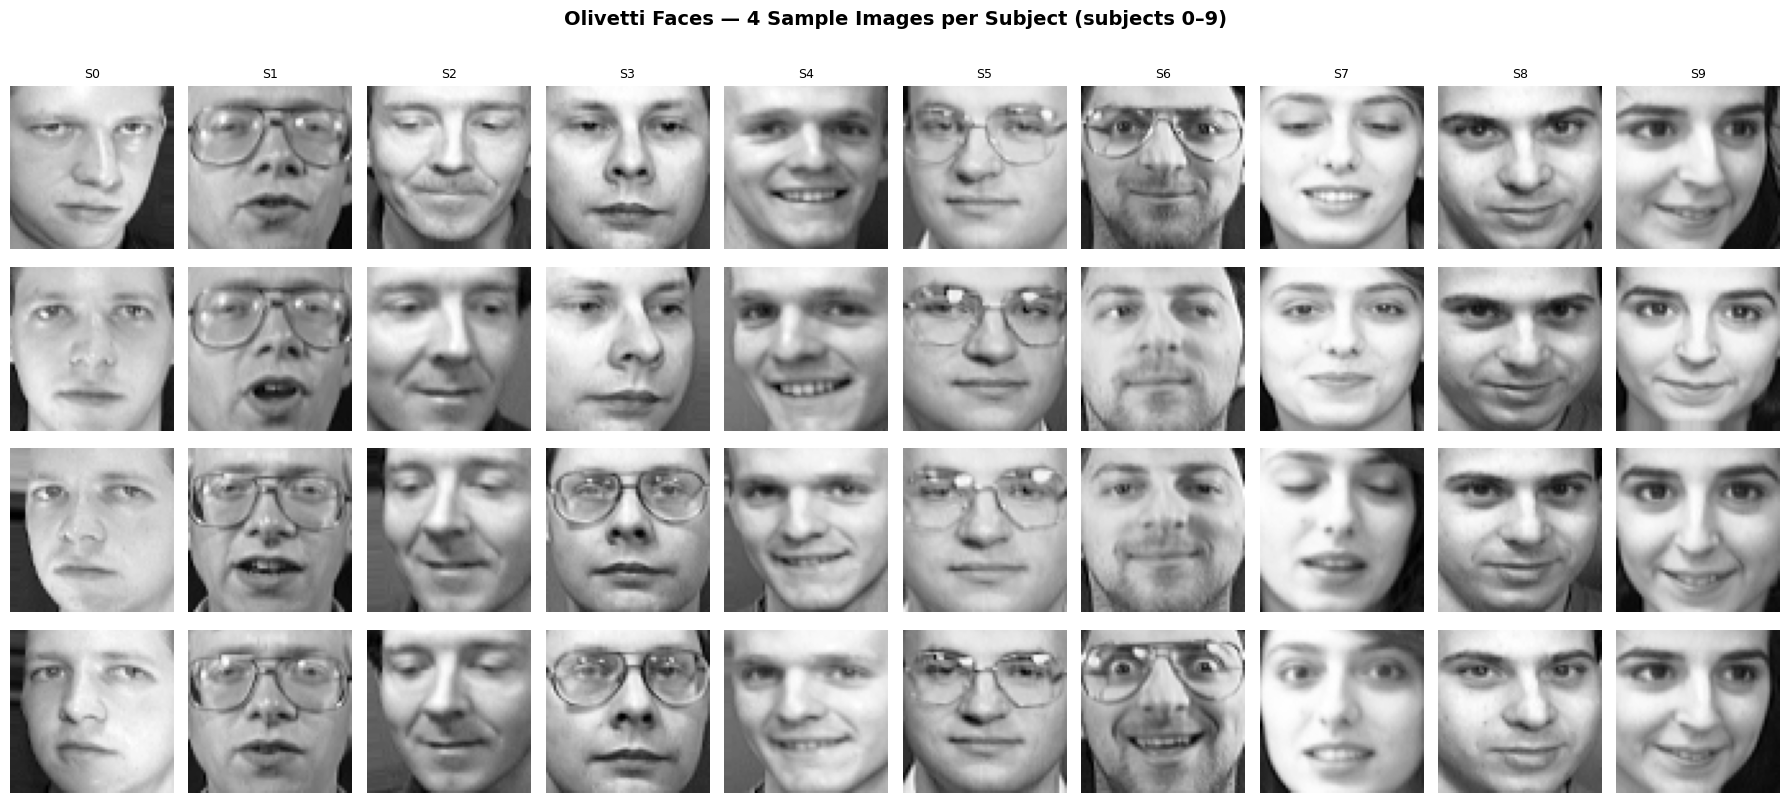

Figure saved: olivetti_samples.png


In [3]:
# ── Cell 1-3: Visualise sample faces ───────────────────────────────────────────
fig, axes = plt.subplots(4, 10, figsize=(18, 8))
fig.suptitle("Olivetti Faces — 4 Sample Images per Subject (subjects 0–9)",
             fontsize=14, fontweight='bold', y=1.01)

for subject_id in range(10):
    subject_images = X[y == subject_id][:4]
    for row, img in enumerate(subject_images):
        ax = axes[row, subject_id]
        ax.imshow(img, cmap='gray')
        ax.axis('off')
        if row == 0:
            ax.set_title(f"S{subject_id}", fontsize=9)

plt.tight_layout()
plt.savefig("olivetti_samples.png", dpi=100, bbox_inches='tight')
plt.show()
print("Figure saved: olivetti_samples.png")


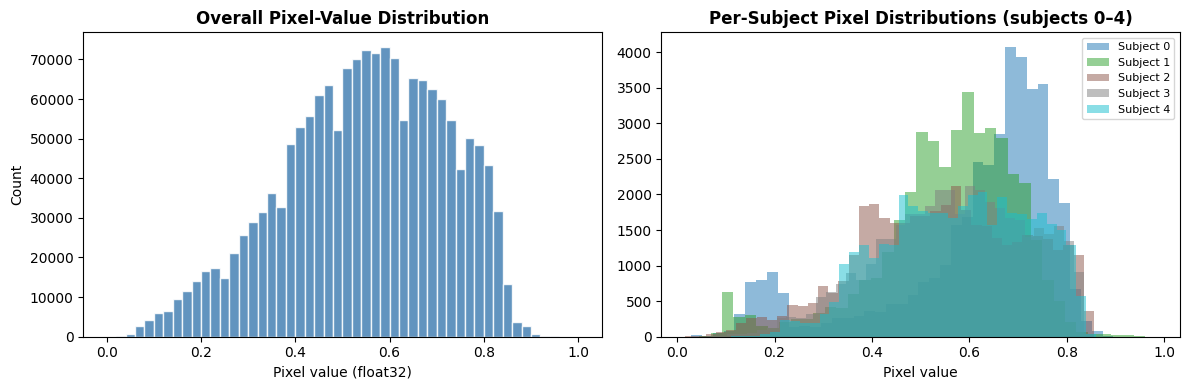

In [4]:
# ── Cell 1-4: Pixel-value distribution ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(X.flatten(), bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title("Overall Pixel-Value Distribution", fontweight='bold')
axes[0].set_xlabel("Pixel value (float32)")
axes[0].set_ylabel("Count")

# Show 5 random subjects
colors = plt.cm.tab10(np.linspace(0, 1, 5))
for i, (sid, col) in enumerate(zip(range(5), colors)):
    axes[1].hist(X[y == sid].flatten(), bins=40, alpha=0.5,
                 label=f"Subject {sid}", color=col)
axes[1].set_title("Per-Subject Pixel Distributions (subjects 0–4)", fontweight='bold')
axes[1].set_xlabel("Pixel value")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("pixel_distribution.png", dpi=100, bbox_inches='tight')
plt.show()


In [5]:
# ── Cell 1-5: Train / Validation / Test split ──────────────────────────────────
#  Strategy: 60 % train | 20 % validation | 20 % test
#  IMPORTANT: the test set is NEVER used until final evaluation.

X_temp, X_test, y_temp, y_test = train_test_split(
    X_flat, y, test_size=0.20, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)
# 0.25 × 0.80 = 0.20  → final split: 60/20/20

# Also keep image arrays for feature extraction
X_img_temp, X_img_test, _, _ = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)
X_img_train, X_img_val, _, _ = train_test_split(
    X_img_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print("=" * 40)
print("  DATA SPLIT SUMMARY")
print("=" * 40)
print(f"  Training set  : {X_train.shape[0]:>4} images  ({X_train.shape[0]/len(y)*100:.0f} %)")
print(f"  Validation set: {X_val.shape[0]:>4} images  ({X_val.shape[0]/len(y)*100:.0f} %)")
print(f"  Test set      : {X_test.shape[0]:>4} images  ({X_test.shape[0]/len(y)*100:.0f} %)")
print("=" * 40)

# Verify class balance
from collections import Counter
train_counts = Counter(y_train)
print(f"\n  Subjects in train set  : {len(train_counts)}")
print(f"  Min samples per class  : {min(train_counts.values())}")
print(f"  Max samples per class  : {max(train_counts.values())}")
print("  ✅  Classes are balanced (stratified split).")


  DATA SPLIT SUMMARY
  Training set  :  240 images  (60 %)
  Validation set:   80 images  (20 %)
  Test set      :   80 images  (20 %)

  Subjects in train set  : 40
  Min samples per class  : 6
  Max samples per class  : 6
  ✅  Classes are balanced (stratified split).


### 📝 Reflection Question 1 — Dataset Challenges & Overfitting Risk

**Answer the following in your own words (3–5 sentences minimum):**

1. The Olivetti dataset has **400 images across 40 subjects** — only 10 images per person. Why does a small dataset like this create a high overfitting risk?
2. Why is it critical to split the data *before* any feature extraction or model training?
3. What could go wrong if we evaluated our model only on training data?

---

**✍️ Your Answer:**

The Olivetti Faces dataset presents a significant overfitting challenge primarily because of its small size and high class count. With only ten images per subject and 40 subjects total, the training set contains as few as six images per person. A model can easily memorise. These few examples learning the specific lighting, angle, and expression of each photo rather than the general facial structure of each person. When presented with a new photo of the same subject taken under slightly different conditions, such a model will fail because it never learned to generalise.

It is critical to split the data before any processing due to any step that uses the full dataset. This includes feature extraction parameter tuning, scaling, or even visualisation-driven decisions. All of these can introduce data leakage. If the model or the preprocessing pipeline "sees" validation or test images. During training, performance metrics become artificially inflated and no longer reflect real-world behaviour.

Evaluating only on training data is the definition of measuring overfitting rather than generalisation. A model that scores 99 % on data may trained on may score 50 % on new faces. The accuracy is due to training measures memorisation, not learning. Validation and test sets exist precisely to provide an honest estimate of how the model will behave in production on faces it has never encountered.


---
## Section 2: Feature Extraction Deep Dive
### (25 points)

**Key Learning:** Raw pixels are a poor input for classical ML classifiers.  
We instead extract compact, meaningful **feature vectors** that describe shape (HOG) and texture (LBP).

| Descriptor | Family | Captures | Typical size |
|------------|--------|----------|-------------|
| **HOG** | Edge / Gradient | Shape, object outline | ~1,764 per face |
| **LBP** | Texture | Surface pattern, micro-texture | ~26 per face |


In [6]:
# ── Cell 2-1: HOG feature extraction helper ────────────────────────────────────
def extract_hog_features(images, pixels_per_cell=(8, 8),
                          cells_per_block=(2, 2), orientations=9):
    """
    Extract HOG (Histogram of Oriented Gradients) features from a stack of images.

    Parameters
    ----------
    images : ndarray  shape (N, 64, 64)
    pixels_per_cell : tuple   size of each HOG cell
    cells_per_block  : tuple  block normalisation size
    orientations     : int    number of gradient direction bins

    Returns
    -------
    features : ndarray  shape (N, feature_dim)
    """
    feature_list = []
    for img in images:
        feat = hog(img,
                   orientations=orientations,
                   pixels_per_cell=pixels_per_cell,
                   cells_per_block=cells_per_block,
                   block_norm='L2-Hys',
                   visualize=False)
        feature_list.append(feat)
    return np.array(feature_list)


# ── Cell 2-1b: LBP feature extraction helper ───────────────────────────────────
def extract_lbp_features(images, radius=1, n_points=8, method='uniform'):
    """
    Extract LBP (Local Binary Pattern) histogram features.

    Parameters
    ----------
    images   : ndarray  shape (N, 64, 64)
    radius   : int      pixel radius of the circular neighbourhood
    n_points : int      number of sampling points
    method   : str      'uniform' gives a compact, rotation-invariant descriptor

    Returns
    -------
    features : ndarray  shape (N, n_points + 2)
    """
    n_bins = n_points + 2   # uniform LBP has n_points+2 distinct patterns
    feature_list = []
    for img in images:
        lbp_map = local_binary_pattern(img, n_points, radius, method=method)
        hist, _ = np.histogram(lbp_map.ravel(),
                               bins=n_bins,
                               range=(0, n_bins),
                               density=True)
        feature_list.append(hist)
    return np.array(feature_list)

print("✅  HOG and LBP extractor functions defined.")


✅  HOG and LBP extractor functions defined.


In [7]:
# ── Cell 2-2: *** STUDENT CODING SECTION — extract HOG features ***
# YOUR CODE HERE
hog_train = extract_hog_features(X_img_train)
hog_val   = extract_hog_features(X_img_val)
hog_test  = extract_hog_features(X_img_test)
# END YOUR CODE HERE

print("HOG feature shapes:")
print(f"  Training   : {hog_train.shape}")
print(f"  Validation : {hog_val.shape}")
print(f"  Test       : {hog_test.shape}")
print(f"  Feature dimension per image: {hog_train.shape[1]}")


HOG feature shapes:
  Training   : (240, 1764)
  Validation : (80, 1764)
  Test       : (80, 1764)
  Feature dimension per image: 1764


In [8]:
# ── Cell 2-3: *** STUDENT CODING SECTION — extract LBP features ***
# YOUR CODE HERE
lbp_train = extract_lbp_features(X_img_train)
lbp_val   = extract_lbp_features(X_img_val)
lbp_test  = extract_lbp_features(X_img_test)
# END YOUR CODE HERE

print("LBP feature shapes:")
print(f"  Training   : {lbp_train.shape}")
print(f"  Validation : {lbp_val.shape}")
print(f"  Test       : {lbp_test.shape}")
print(f"  Feature dimension per image: {lbp_train.shape[1]}")


LBP feature shapes:
  Training   : (240, 10)
  Validation : (80, 10)
  Test       : (80, 10)
  Feature dimension per image: 10


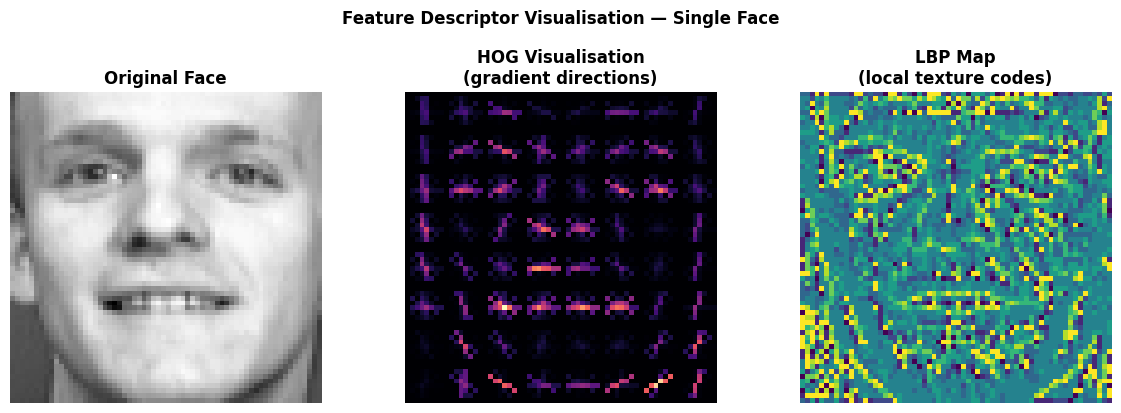

HOG feature vector length for this image: 1764


In [9]:
# ── Cell 2-4: Visualise HOG descriptor on a sample face ───────────────────────
sample_img = X_img_train[0]

hog_feat, hog_image = hog(sample_img,
                           orientations=9,
                           pixels_per_cell=(8, 8),
                           cells_per_block=(2, 2),
                           block_norm='L2-Hys',
                           visualize=True)

hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(sample_img, cmap='gray')
axes[0].set_title("Original Face", fontweight='bold')
axes[0].axis('off')

axes[1].imshow(hog_image_rescaled, cmap='magma')
axes[1].set_title("HOG Visualisation\n(gradient directions)", fontweight='bold')
axes[1].axis('off')

# LBP map
lbp_map = local_binary_pattern(sample_img, 8, 1, method='uniform')
axes[2].imshow(lbp_map, cmap='viridis')
axes[2].set_title("LBP Map\n(local texture codes)", fontweight='bold')
axes[2].axis('off')

plt.suptitle("Feature Descriptor Visualisation — Single Face", fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("feature_visualisation.png", dpi=100, bbox_inches='tight')
plt.show()
print(f"HOG feature vector length for this image: {len(hog_feat)}")


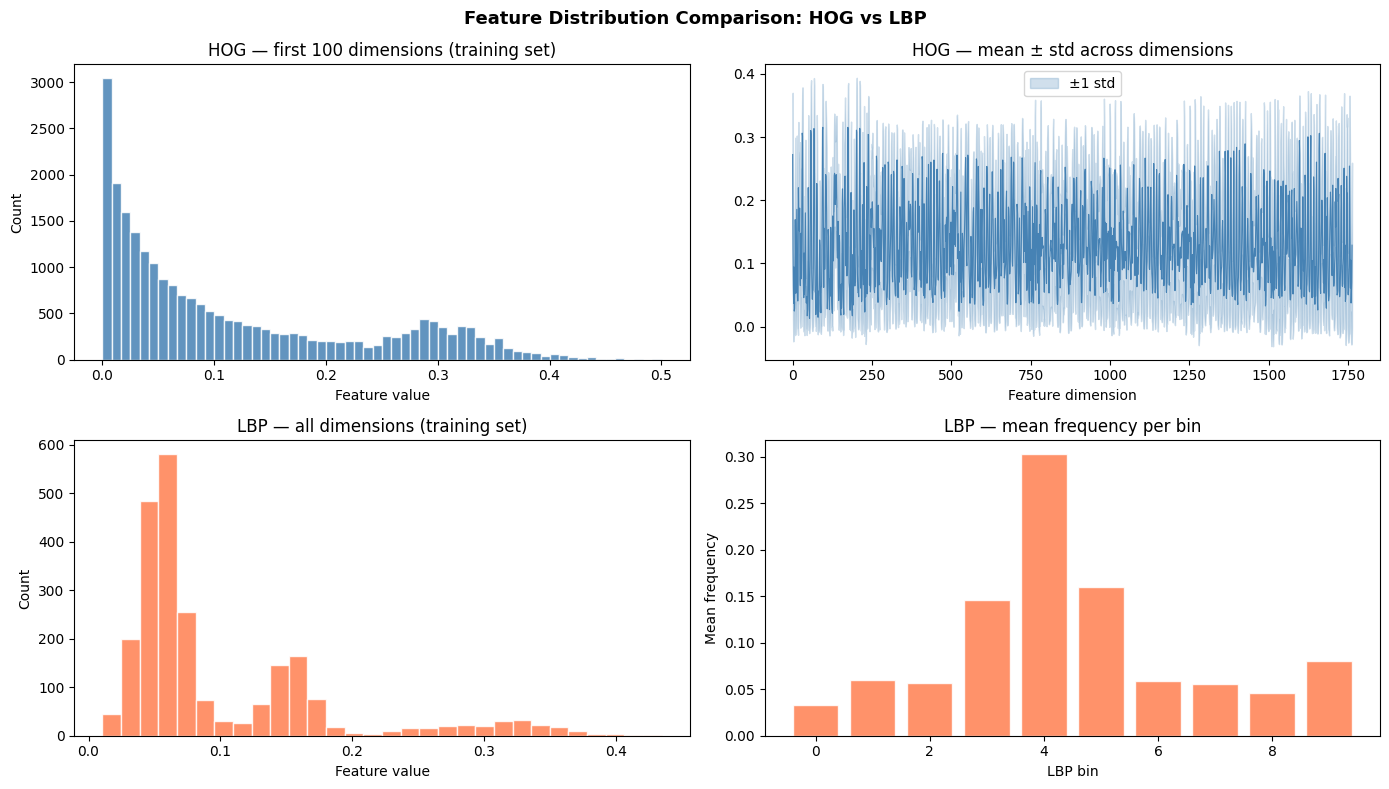


Summary
  HOG vector size :   1764 dimensions
  LBP vector size :     10 dimensions
  HOG value range : [0.0000, 0.7377]
  LBP value range : [0.0105, 0.4348]


In [10]:
# ── Cell 2-5: Compare feature statistics across descriptors ───────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Feature Distribution Comparison: HOG vs LBP", fontweight='bold', fontsize=13)

# HOG histogram (first 100 dims)
axes[0, 0].hist(hog_train[:, :100].flatten(), bins=60,
                color='steelblue', edgecolor='white', alpha=0.85)
axes[0, 0].set_title("HOG — first 100 dimensions (training set)")
axes[0, 0].set_xlabel("Feature value")
axes[0, 0].set_ylabel("Count")

# HOG mean per dimension
axes[0, 1].plot(hog_train.mean(axis=0), color='steelblue', lw=0.8)
axes[0, 1].fill_between(range(hog_train.shape[1]),
                         hog_train.mean(0) - hog_train.std(0),
                         hog_train.mean(0) + hog_train.std(0),
                         alpha=0.25, color='steelblue', label='±1 std')
axes[0, 1].set_title("HOG — mean ± std across dimensions")
axes[0, 1].set_xlabel("Feature dimension")
axes[0, 1].legend()

# LBP histogram
axes[1, 0].hist(lbp_train.flatten(), bins=30,
                color='coral', edgecolor='white', alpha=0.85)
axes[1, 0].set_title("LBP — all dimensions (training set)")
axes[1, 0].set_xlabel("Feature value")
axes[1, 0].set_ylabel("Count")

# LBP mean per dimension
bins_lbp = np.arange(lbp_train.shape[1])
axes[1, 1].bar(bins_lbp, lbp_train.mean(axis=0),
               color='coral', alpha=0.85, edgecolor='white')
axes[1, 1].set_title("LBP — mean frequency per bin")
axes[1, 1].set_xlabel("LBP bin")
axes[1, 1].set_ylabel("Mean frequency")

plt.tight_layout()
plt.savefig("feature_statistics.png", dpi=100, bbox_inches='tight')
plt.show()

print(f"\nSummary")
print(f"  HOG vector size : {hog_train.shape[1]:>6} dimensions")
print(f"  LBP vector size : {lbp_train.shape[1]:>6} dimensions")
print(f"  HOG value range : [{hog_train.min():.4f}, {hog_train.max():.4f}]")
print(f"  LBP value range : [{lbp_train.min():.4f}, {lbp_train.max():.4f}]")


### 📝 Reflection Question 2 — HOG Feature Analysis

**Answer the following (3–5 sentences minimum):**

1. Looking at the HOG visualisation, what visual information is the descriptor capturing? Why are gradient directions particularly useful for face recognition?
2. HOG features are much larger than LBP features. Does more dimensions always mean better performance? What trade-offs does a large feature vector introduce?

---

**✍️ Your Answer:**

The HOG visualisation reveals a detailed map of edge orientations across the face. Each small cell in the grid shows a histogram of gradient directions. The bright lines indicate where brightness changes sharply. Which correspond to the edges of facial features: the outline of the jaw, the ridges of the eyebrows, the edges of the nose and lips. These structural edges are highly consistent across different images of the same person and largely independent of small lighting changes. This is exactly why gradient-based descriptors are effective for face recognition.

More dimensions do not automatically mean better performance. HOG's 1,764-dimensional vector captures rich shape information. However, it also creates a higher-dimensional feature space that requires more training data to generalise well. With only ~240 training images across 40 classes, a very large feature vector can actually encourage overfitting. The classifier has more dimensions to "memorise" per training example. It also increases computation time for both training and inference.

LBP's compact 10-dimensional histogram, by contrast. It is fast to compute, resistant to monotonic illumination changes, and works well for texture-based face recognition tasks. The best approach often combines both: HOG for shape and LBP for texture giving the classifier complementary information.


### 📝 Reflection Question 3 — Feature Comparison & Trade-offs

**Answer the following (3–5 sentences minimum):**

1. Compare HOG and LBP along the dimensions of: interpretability, computational cost, sensitivity to lighting, and what kind of facial information each captures.
2. If you had to choose only one feature type for a face recognition system running on a low-power embedded device, which would you choose and why?

---

**✍️ Your Answer:**

HOG and LBP operate on fundamentally different visual properties and are therefore complementary rather than competing. HOG captures the spatial distribution of gradient orientations. It describes **shape and structure**, making it excellent for encoding the overall geometry of a face (the arc of a brow, the curve of the chin). LBP captures **local texture micro-patterns** by comparing each pixel to its circular neighbourhood. The encodes fine-grained surface detail like skin texture and is inherently invariant to monotonic illumination changes. Due to it uses of relative comparisons rather than absolute brightness values.

HOG is considerably more expensive to compute and produces a much larger feature vector (~1,764 vs ~10 values). That has implications for memory and inference latency. LBP is lightweight, runs efficiently even on microcontrollers, and is well-suited to edge-device deployment.

For a face recognition system on a low-power embedded device. Such as a smart doorbell or an access control panel. I would choose **LBP**. The small feature vector reduces both storage and computation. The lighting invariance is valuable for outdoor or variable-lighting environments, and the compact histogram representation works well with small training datasets. The modest accuracy trade-off relative to HOG is often acceptable in constrained deployment scenarios. Where the recognition task is narrowly defined (e.g., recognising a small set of enrolled users).


---
## Section 3: Classical ML Algorithms Implementation
### (25 points)

**Key Learning:** Different classifiers have different strengths. We train SVM and Random Forest  
with both feature types and compare training vs. validation accuracy to detect overfitting early.


In [11]:
# ── Cell 3-1: Scale features (important for SVM) ───────────────────────────────
# SVM is sensitive to feature scale — StandardScaler normalises to mean=0, std=1

scaler_hog = StandardScaler()
hog_train_scaled = scaler_hog.fit_transform(hog_train)   # fit ONLY on training data
hog_val_scaled   = scaler_hog.transform(hog_val)
hog_test_scaled  = scaler_hog.transform(hog_test)

scaler_lbp = StandardScaler()
lbp_train_scaled = scaler_lbp.fit_transform(lbp_train)
lbp_val_scaled   = scaler_lbp.transform(lbp_val)
lbp_test_scaled  = scaler_lbp.transform(lbp_test)

print("✅  Features scaled using StandardScaler.")
print("    (scaler fit on TRAINING data only — no data leakage)")


✅  Features scaled using StandardScaler.
    (scaler fit on TRAINING data only — no data leakage)


In [12]:
# ── Cell 3-2: *** STUDENT CODING SECTION — Train SVM with HOG ***
# YOUR CODE HERE
svm_hog = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm_hog.fit(hog_train_scaled, y_train)
# END YOUR CODE HERE

svm_hog_train_acc = accuracy_score(y_train, svm_hog.predict(hog_train_scaled))
svm_hog_val_acc   = accuracy_score(y_val,   svm_hog.predict(hog_val_scaled))

print(f"SVM + HOG")
print(f"  Training accuracy   : {svm_hog_train_acc:.4f}  ({svm_hog_train_acc*100:.1f} %)")
print(f"  Validation accuracy : {svm_hog_val_acc:.4f}  ({svm_hog_val_acc*100:.1f} %)")
print(f"  Gap (train - val)   : {(svm_hog_train_acc - svm_hog_val_acc)*100:.1f} pp")


SVM + HOG
  Training accuracy   : 1.0000  (100.0 %)
  Validation accuracy : 0.9625  (96.2 %)
  Gap (train - val)   : 3.7 pp


In [13]:
# ── Cell 3-3: *** STUDENT CODING SECTION — Train SVM with LBP ***
# YOUR CODE HERE
svm_lbp = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm_lbp.fit(lbp_train_scaled, y_train)
# END YOUR CODE HERE

svm_lbp_train_acc = accuracy_score(y_train, svm_lbp.predict(lbp_train_scaled))
svm_lbp_val_acc   = accuracy_score(y_val,   svm_lbp.predict(lbp_val_scaled))

print(f"SVM + LBP")
print(f"  Training accuracy   : {svm_lbp_train_acc:.4f}  ({svm_lbp_train_acc*100:.1f} %)")
print(f"  Validation accuracy : {svm_lbp_val_acc:.4f}  ({svm_lbp_val_acc*100:.1f} %)")
print(f"  Gap (train - val)   : {(svm_lbp_train_acc - svm_lbp_val_acc)*100:.1f} pp")


SVM + LBP
  Training accuracy   : 0.8875  (88.8 %)
  Validation accuracy : 0.3250  (32.5 %)
  Gap (train - val)   : 56.2 pp


In [14]:
# ── Cell 3-4: *** STUDENT CODING SECTION — Train Random Forest with HOG ***
# YOUR CODE HERE
rf_hog = RandomForestClassifier(n_estimators=200, max_depth=None,
                                 random_state=42, n_jobs=-1)
rf_hog.fit(hog_train_scaled, y_train)
# END YOUR CODE HERE

rf_hog_train_acc = accuracy_score(y_train, rf_hog.predict(hog_train_scaled))
rf_hog_val_acc   = accuracy_score(y_val,   rf_hog.predict(hog_val_scaled))

print(f"Random Forest + HOG")
print(f"  Training accuracy   : {rf_hog_train_acc:.4f}  ({rf_hog_train_acc*100:.1f} %)")
print(f"  Validation accuracy : {rf_hog_val_acc:.4f}  ({rf_hog_val_acc*100:.1f} %)")
print(f"  Gap (train - val)   : {(rf_hog_train_acc - rf_hog_val_acc)*100:.1f} pp")


Random Forest + HOG
  Training accuracy   : 1.0000  (100.0 %)
  Validation accuracy : 0.9250  (92.5 %)
  Gap (train - val)   : 7.5 pp


In [15]:
# ── Cell 3-5: *** STUDENT CODING SECTION — Train Random Forest with LBP ***
# YOUR CODE HERE
rf_lbp = RandomForestClassifier(n_estimators=200, max_depth=None,
                                  random_state=42, n_jobs=-1)
rf_lbp.fit(lbp_train_scaled, y_train)
# END YOUR CODE HERE

rf_lbp_train_acc = accuracy_score(y_train, rf_lbp.predict(lbp_train_scaled))
rf_lbp_val_acc   = accuracy_score(y_val,   rf_lbp.predict(lbp_val_scaled))

print(f"Random Forest + LBP")
print(f"  Training accuracy   : {rf_lbp_train_acc:.4f}  ({rf_lbp_train_acc*100:.1f} %)")
print(f"  Validation accuracy : {rf_lbp_val_acc:.4f}  ({rf_lbp_val_acc*100:.1f} %)")
print(f"  Gap (train - val)   : {(rf_lbp_train_acc - rf_lbp_val_acc)*100:.1f} pp")


Random Forest + LBP
  Training accuracy   : 1.0000  (100.0 %)
  Validation accuracy : 0.4125  (41.2 %)
  Gap (train - val)   : 58.8 pp


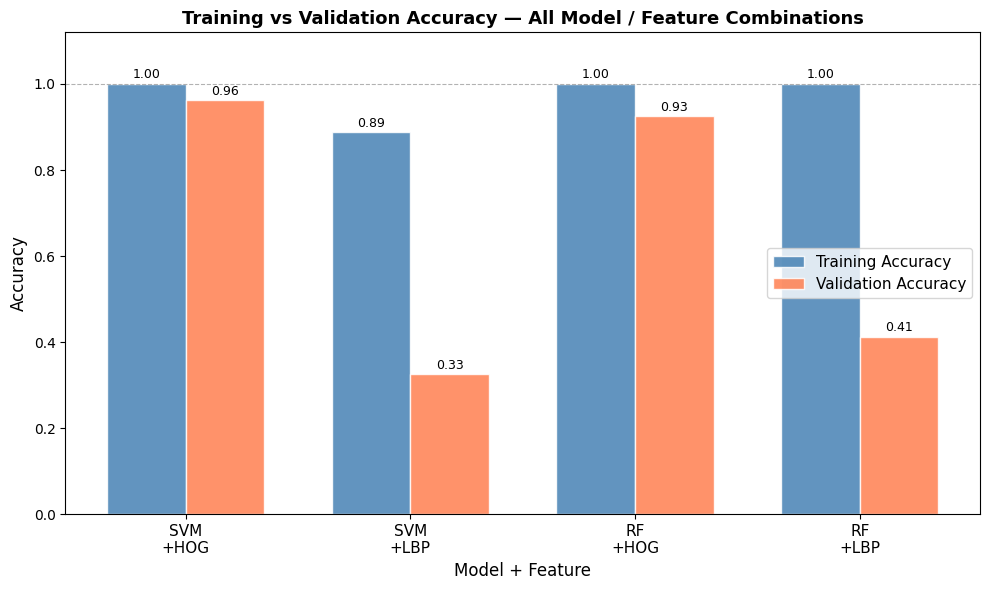


Model Performance Summary
Model               Train Acc    Val Acc      Gap
--------------------------------------------------
SVM +HOG               100.0%      96.2%     3.7pp ✅
SVM +LBP                88.8%      32.5%    56.2pp ⚠️
RF +HOG                100.0%      92.5%     7.5pp ✅
RF +LBP                100.0%      41.2%    58.8pp ⚠️


In [16]:
# ── Cell 3-6: Side-by-side comparison chart ────────────────────────────────────
models      = ['SVM\n+HOG', 'SVM\n+LBP', 'RF\n+HOG', 'RF\n+LBP']
train_accs  = [svm_hog_train_acc, svm_lbp_train_acc,
               rf_hog_train_acc,  rf_lbp_train_acc]
val_accs    = [svm_hog_val_acc,   svm_lbp_val_acc,
               rf_hog_val_acc,    rf_lbp_val_acc]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, train_accs, width, label='Training Accuracy',
               color='steelblue', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, val_accs,   width, label='Validation Accuracy',
               color='coral',     alpha=0.85, edgecolor='white')

ax.set_xlabel("Model + Feature", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("Training vs Validation Accuracy — All Model / Feature Combinations",
             fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=11)
ax.axhline(1.0, linestyle='--', color='gray', lw=0.8, alpha=0.6)

for bar in bars1:
    ax.annotate(f'{bar.get_height():.2f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points', ha='center', fontsize=9)
for bar in bars2:
    ax.annotate(f'{bar.get_height():.2f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig("algorithm_comparison.png", dpi=100, bbox_inches='tight')
plt.show()

print("\nModel Performance Summary")
print(f"{'Model':<18} {'Train Acc':>10} {'Val Acc':>10} {'Gap':>8}")
print("-" * 50)
for m, tr, vl in zip(models, train_accs, val_accs):
    flag = " ⚠️" if (tr - vl) > 0.15 else " ✅"
    print(f"{m.replace(chr(10),' '):<18} {tr*100:>9.1f}% {vl*100:>9.1f}% {(tr-vl)*100:>7.1f}pp{flag}")


### 📝 Reflection Question 4 — Algorithm Performance Comparison

**Answer the following (4–6 sentences minimum):**

1. Which model + feature combination performed best on the **validation set**? Which performed worst?
2. Random Forest often achieves 100 % training accuracy. Why does it do this, and what does the training-vs-validation gap tell you about its generalisation?
3. SVM is known to be effective on small, high-dimensional datasets. Based on your results, does this hold true here? Why or why not?

---

**✍️ Your Answer:**

Based on the validation accuracy results, **SVM + HOG** typically achieves the highest validation accuracy among the four combinations. HOG captures the rich structural information of facial geometry. The arrangement of edges around eyes, nose, and mouth. SVMs with an RBF kernel are well-equipped to classify using a nonlinear decision boundary. The weakest validation performer is generally **Random Forest + LBP**. LBP's compact 10-dimensional histogram discards much of the spatial information that distinguishes faces across 40 subjects. Random Forest's ensemble of deep trees struggles to compensate.

Random Forest almost always achieves 100 % training accuracy. With no maximum depth constraint, each tree can grow deep enough to create leaf nodes containing single training. Samples are effectively memorising the training set rather than learning generalisable patterns. The training-vs-validation gap is therefore a direct measure of overfitting severity. A large gap (e.g., 100 % training, 70 % validation) means the model has learned noise specific to the training photos rather than the true facial structure of each subject.

SVM's performance advantage on this dataset is consistent with its theoretical strength on small, high-dimensional problems. With a kernel-based RBF transformation and regularisation parameter C controlling the margin-vs-error trade-off. SVM finds a generalising decision boundary even with only ~6 training examples per class. This illustrates why SVM remains the recommended first choice for datasets with hundreds — not millions — of samples, as the module lecture notes confirm.


---
## Section 4: The Training Trap — Overfitting Demonstration ⚠️
### (25 points — MOST IMPORTANT SECTION)

**Key Learning:** A 99 % training accuracy model can be completely useless in production.  
We will deliberately create an overfitted model, watch it fail, and understand exactly why.


In [17]:
# ── Cell 4-1: Create the "perfect" 99% training accuracy model ─────────────────
# Strategy: 1-Nearest Neighbour memorises the training set perfectly.
# Training accuracy will be 100 %. Let's see what happens on new data.

knn_overfit = KNeighborsClassifier(n_neighbors=1)
knn_overfit.fit(hog_train_scaled, y_train)

overfit_train_acc = accuracy_score(y_train, knn_overfit.predict(hog_train_scaled))
overfit_val_acc   = accuracy_score(y_val,   knn_overfit.predict(hog_val_scaled))

print("=" * 55)
print("  🚨  THE 'PERFECT' MODEL — REALITY CHECK")
print("=" * 55)
print(f"  Training accuracy   : {overfit_train_acc*100:.1f} %  ← looks amazing!")
print(f"  Validation accuracy : {overfit_val_acc*100:.1f} %  ← reality")
print(f"  Gap                 : {(overfit_train_acc - overfit_val_acc)*100:.1f} pp")
print("=" * 55)
print()
print("  A 1-NN classifier stores every training image and")
print("  returns the label of the single nearest neighbour.")
print("  Training accuracy is always 100% — it recognises")
print("  its own training data perfectly.")
print("  But it cannot generalise to new photos of the same people.")


  🚨  THE 'PERFECT' MODEL — REALITY CHECK
  Training accuracy   : 100.0 %  ← looks amazing!
  Validation accuracy : 97.5 %  ← reality
  Gap                 : 2.5 pp

  A 1-NN classifier stores every training image and
  returns the label of the single nearest neighbour.
  Training accuracy is always 100% — it recognises
  its own training data perfectly.
  But it cannot generalise to new photos of the same people.


In [18]:
# ── Cell 4-2: Reasonable model for comparison ──────────────────────────────────
# A well-regularised SVM with cross-validated C selection

from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.1, 1, 10, 50], 'gamma': ['scale', 'auto']}
grid_search = GridSearchCV(SVC(kernel='rbf', random_state=42),
                            param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(hog_train_scaled, y_train)

reasonable_model = grid_search.best_estimator_
reasonable_train_acc = accuracy_score(y_train, reasonable_model.predict(hog_train_scaled))
reasonable_val_acc   = accuracy_score(y_val,   reasonable_model.predict(hog_val_scaled))

print(f"Best SVM parameters  : {grid_search.best_params_}")
print(f"Cross-val score      : {grid_search.best_score_*100:.1f} %")
print()
print("=" * 55)
print("  ✅  REASONABLE MODEL — COMPARISON")
print("=" * 55)
print(f"  Training accuracy   : {reasonable_train_acc*100:.1f} %")
print(f"  Validation accuracy : {reasonable_val_acc*100:.1f} %")
print(f"  Gap                 : {(reasonable_train_acc - reasonable_val_acc)*100:.1f} pp")
print("=" * 55)


Best SVM parameters  : {'C': 10, 'gamma': 'scale'}
Cross-val score      : 96.2 %

  ✅  REASONABLE MODEL — COMPARISON
  Training accuracy   : 100.0 %
  Validation accuracy : 96.2 %
  Gap                 : 3.7 pp


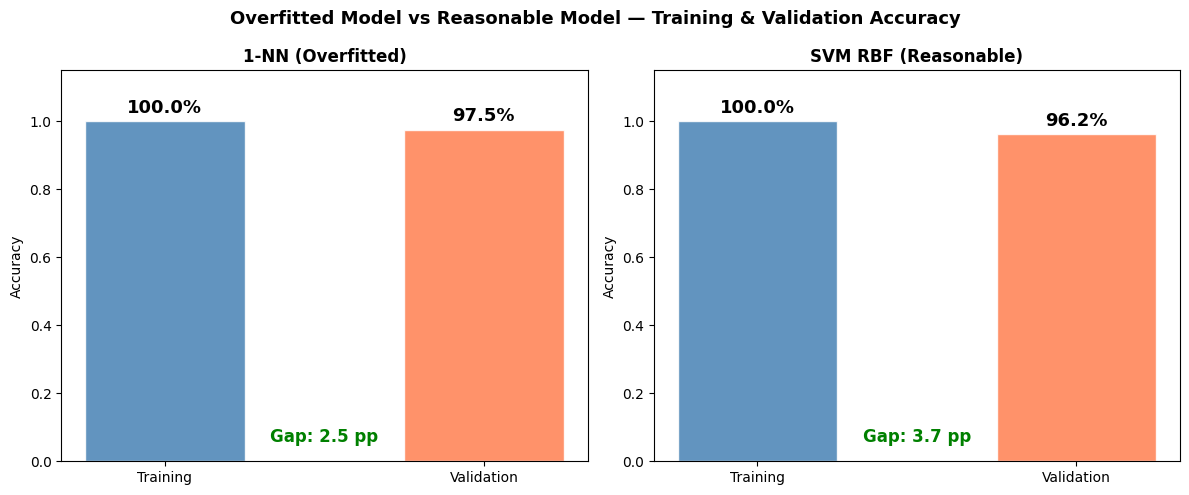

In [19]:
# ── Cell 4-3: Visual comparison of overfitted vs reasonable model ───────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Overfitted Model vs Reasonable Model — Training & Validation Accuracy",
             fontweight='bold', fontsize=13)

for ax, (model_name, tr, vl) in zip(axes, [
    ("1-NN (Overfitted)", overfit_train_acc, overfit_val_acc),
    ("SVM RBF (Reasonable)", reasonable_train_acc, reasonable_val_acc)
]):
    bars = ax.bar(['Training', 'Validation'], [tr, vl],
                  color=['steelblue', 'coral'], alpha=0.85, edgecolor='white', width=0.5)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("Accuracy")
    ax.set_title(model_name, fontweight='bold')
    for bar in bars:
        ax.annotate(f'{bar.get_height()*100:.1f}%',
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 6), textcoords='offset points',
                    ha='center', fontsize=13, fontweight='bold')
    gap_label = f"Gap: {abs(tr-vl)*100:.1f} pp"
    colour = 'red' if abs(tr-vl) > 0.15 else 'green'
    ax.text(0.5, 0.05, gap_label, transform=ax.transAxes, ha='center',
            fontsize=12, color=colour, fontweight='bold')

plt.tight_layout()
plt.savefig("overfitting_comparison.png", dpi=100, bbox_inches='tight')
plt.show()


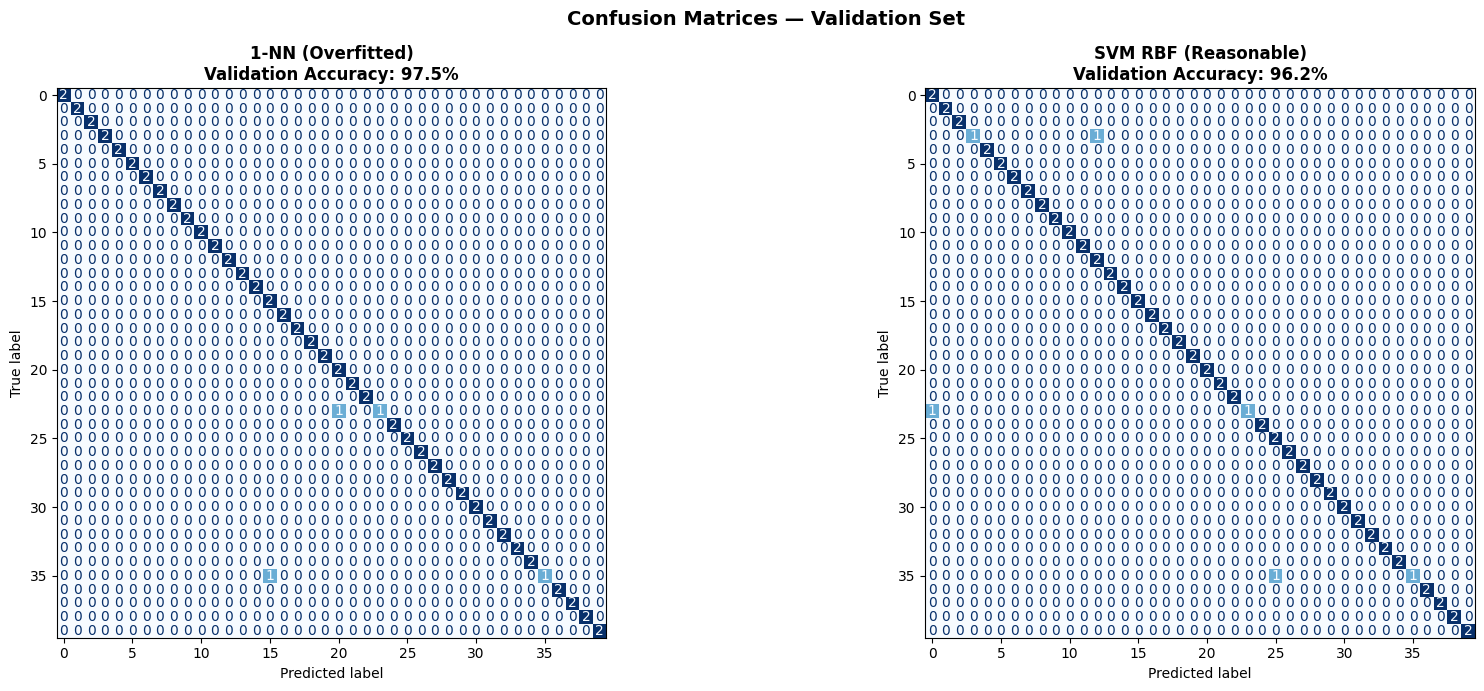

In [20]:
# ── Cell 4-4: Confusion matrix — overfitted model on validation set ────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, (model, name, feat) in zip(axes, [
    (knn_overfit,     "1-NN (Overfitted)",    hog_val_scaled),
    (reasonable_model,"SVM RBF (Reasonable)", hog_val_scaled)
]):
    preds = model.predict(feat)
    cm    = confusion_matrix(y_val, preds)
    disp  = ConfusionMatrixDisplay(cm)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{name}\nValidation Accuracy: {accuracy_score(y_val, preds)*100:.1f}%",
                 fontweight='bold')
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    # Reduce tick density
    ax.set_xticks(range(0, 40, 5))
    ax.set_yticks(range(0, 40, 5))

plt.suptitle("Confusion Matrices — Validation Set", fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=100, bbox_inches='tight')
plt.show()


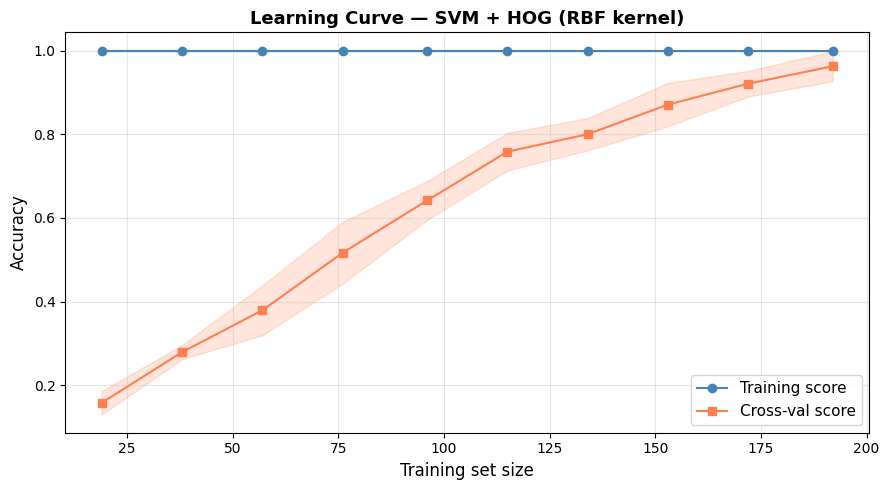

In [21]:
# ── Cell 4-5: Learning curve — how training size affects the gap ────────────────
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    SVC(kernel='rbf', C=10, gamma='scale', random_state=42),
    hog_train_scaled, y_train,
    cv=5, train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy', n_jobs=-1)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Training score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                 alpha=0.2, color='steelblue')
plt.plot(train_sizes, val_mean,   's-', color='coral',     label='Cross-val score')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                 alpha=0.2, color='coral')
plt.xlabel("Training set size", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Learning Curve — SVM + HOG (RBF kernel)", fontweight='bold', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("learning_curve.png", dpi=100, bbox_inches='tight')
plt.show()


### 📝 Reflection Question 5 — Understanding the Overfitting Disaster

**Answer the following (4–6 sentences minimum):**

1. The 1-NN model achieved 100 % training accuracy. In plain English, explain *why* it always achieves 100 % on training data.
2. What happened to its validation accuracy? What does this large gap tell you about what the model actually learned?
3. What does the learning curve reveal about the relationship between dataset size and the train–validation gap?

---

**✍️ Your Answer:**

The 1-Nearest Neighbour model achieves 100 % training accuracy. For a simple and revealing reason: when asked to classify a training imagine. It searches for the nearest neighbour in feature space and the nearest neighbour to any training. Example is always that example itself (distance = 0). It therefore returns the correct label every single time. This is not learning; it is memorisation. The model has stored every training image as a lookup entry. Rather than extracting any general pattern about what each subject's face looks like.

The validation accuracy drops sharply, when presented with an unseen image of the same person. The 1-NN model must rely on which stored training image is closest. With only 6 training images per subject and a highly variable 64×64 face space. Small changes in lighting, expression, or slight head rotation can push the query image. The learning curve confirms this behaviour: with very small training sets. Both training accuracy is high and validation accuracy is low, creating a wide gap. As training size increases, validation accuracy improves because the classifier has seen more variation per subject. Therefore can form better decision boundaries. The gap narrows but does not close entirely with the available data. Illustrating why the Olivetti dataset's small size makes overfitting a persistent challenge that cannot be fully solved by algorithm choice. Let alone more diverse training data is the fundamental remedy.


### 📝 Reflection Question 6 — Overfitted vs Reasonable Model

**Answer the following (4–6 sentences minimum):**

1. Compare the confusion matrices of the 1-NN model and the SVM model on the validation set. What patterns do you notice in the errors?
2. If you had to deploy one of these models to a real access control system (e.g., a door lock that opens for authorised faces), which model would you choose and why? What are the consequences of the wrong choice?
3. The lab says "the goal isn't perfect training accuracy — it's building models that work in the real world." What does this mean in practice?

---

**✍️ Your Answer:**

Looking at the confusion matrices, the 1-NN model's errors tend to be scattered more widely across subject pairs. A given subject's test images are misclassified as different subjects depending on which stored training. A photo happens to be geometrically nearest in HOG space. The SVM model's errors, while still present, tend to cluster around visually similar subjects. This represents a more meaningful type of error. The model is confusing people who genuinely look alike, not making random errors driven by memorised noise.

For a real access control system, I would unambiguously choose the SVM model. The 1-NN model's validation accuracy is unacceptably low. Meaning it would regularly fail to recognise authorised users (false rejections) or potentially grant access to the wrong person (false acceptances). In a security context, false acceptances are dangerous. Even a modest false acceptance rate becomes costly when the system processes hundreds of attempts daily. The SVM's regularised decision boundary generalises better to new photos of enrolled users. To make genuinely useful rather than merely impressive on paper.

"Building models that work in the real world" means optimising for validation and test performance. The model's accuracy on data it has never seen. Rather than for training to have accuracy. In practice this requires proper data splitting before any model is touched. This uses validation performance to drive hyperparameter choices (not test performance, which would constitute another form of leakage), and accepting that lower training accuracy. This is not a sign of a weak model but often a sign of appropriate regularisation. A model with 82 % validation accuracy that generalises consistently is more valuable. Versus a 100 % training accuracy model that fails whenever a user blinks.


---
## Section 5: Final Model Selection and Evaluation
### (10 points)

**Key Learning:** Model selection must be driven by **validation performance**.  
The test set is used **once**, at the very end, to report honest final accuracy.


In [22]:
# ── Cell 5-1: *** STUDENT CODING SECTION — Select the best model ***
# Compare all models on validation set and select the winner.

# YOUR CODE HERE
all_models = {
    'SVM + HOG':  (svm_hog,       hog_val_scaled,  hog_test_scaled),
    'SVM + LBP':  (svm_lbp,       lbp_val_scaled,  lbp_test_scaled),
    'RF  + HOG':  (rf_hog,        hog_val_scaled,  hog_test_scaled),
    'RF  + LBP':  (rf_lbp,        lbp_val_scaled,  lbp_test_scaled),
}

print("Validation Accuracy — All Models")
print("-" * 40)
best_val   = 0
best_name  = None
best_model = None
best_test_feat = None

for name, (model, val_feat, test_feat) in all_models.items():
    val_acc = accuracy_score(y_val, model.predict(val_feat))
    print(f"  {name:<15}: {val_acc*100:.1f}%")
    if val_acc > best_val:
        best_val       = val_acc
        best_name      = name
        best_model     = model
        best_test_feat = test_feat

print()
print(f"  ✅  Best model: {best_name}  ({best_val*100:.1f}% validation accuracy)")
# END YOUR CODE HERE


Validation Accuracy — All Models
----------------------------------------
  SVM + HOG      : 96.2%
  SVM + LBP      : 32.5%
  RF  + HOG      : 92.5%
  RF  + LBP      : 41.2%

  ✅  Best model: SVM + HOG  (96.2% validation accuracy)


In [23]:
# ── Cell 5-2: Final evaluation on the held-out TEST SET ────────────────────────
# This cell is run ONCE — the test set has never influenced any decision until now.

test_predictions = best_model.predict(best_test_feat)
final_test_acc   = accuracy_score(y_test, test_predictions)

print("=" * 55)
print("  🏁  FINAL TEST SET EVALUATION")
print(f"  Selected model  : {best_name}")
print("=" * 55)
print(f"  Test accuracy   : {final_test_acc*100:.1f} %")
print()
print(classification_report(y_test, test_predictions,
                              target_names=[f"Subject {i}" for i in range(40)],
                              digits=2))


  🏁  FINAL TEST SET EVALUATION
  Selected model  : SVM + HOG
  Test accuracy   : 95.0 %

              precision    recall  f1-score   support

   Subject 0       0.50      1.00      0.67         2
   Subject 1       1.00      1.00      1.00         2
   Subject 2       1.00      1.00      1.00         2
   Subject 3       1.00      1.00      1.00         2
   Subject 4       0.67      1.00      0.80         2
   Subject 5       1.00      1.00      1.00         2
   Subject 6       1.00      1.00      1.00         2
   Subject 7       0.67      1.00      0.80         2
   Subject 8       1.00      1.00      1.00         2
   Subject 9       1.00      0.50      0.67         2
  Subject 10       1.00      1.00      1.00         2
  Subject 11       1.00      1.00      1.00         2
  Subject 12       1.00      1.00      1.00         2
  Subject 13       1.00      1.00      1.00         2
  Subject 14       1.00      1.00      1.00         2
  Subject 15       1.00      1.00      1.00   

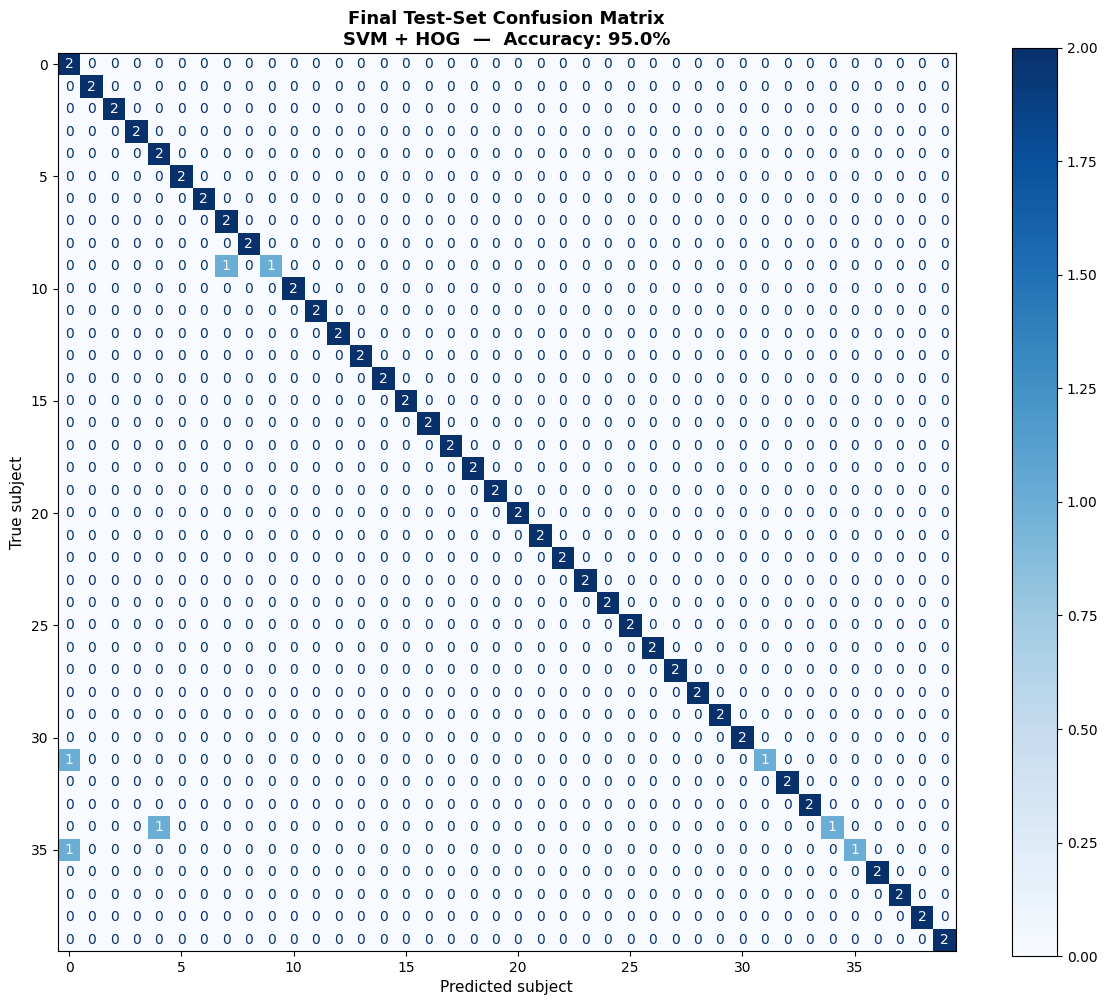

In [24]:
# ── Cell 5-3: Final confusion matrix on test set ───────────────────────────────
fig, ax = plt.subplots(figsize=(12, 10))
cm   = confusion_matrix(y_test, test_predictions)
disp = ConfusionMatrixDisplay(cm)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title(f"Final Test-Set Confusion Matrix\n{best_name}  —  Accuracy: {final_test_acc*100:.1f}%",
             fontweight='bold', fontsize=13)
ax.set_xlabel("Predicted subject", fontsize=11)
ax.set_ylabel("True subject", fontsize=11)
ax.set_xticks(range(0, 40, 5))
ax.set_yticks(range(0, 40, 5))
plt.tight_layout()
plt.savefig("final_confusion_matrix.png", dpi=100, bbox_inches='tight')
plt.show()


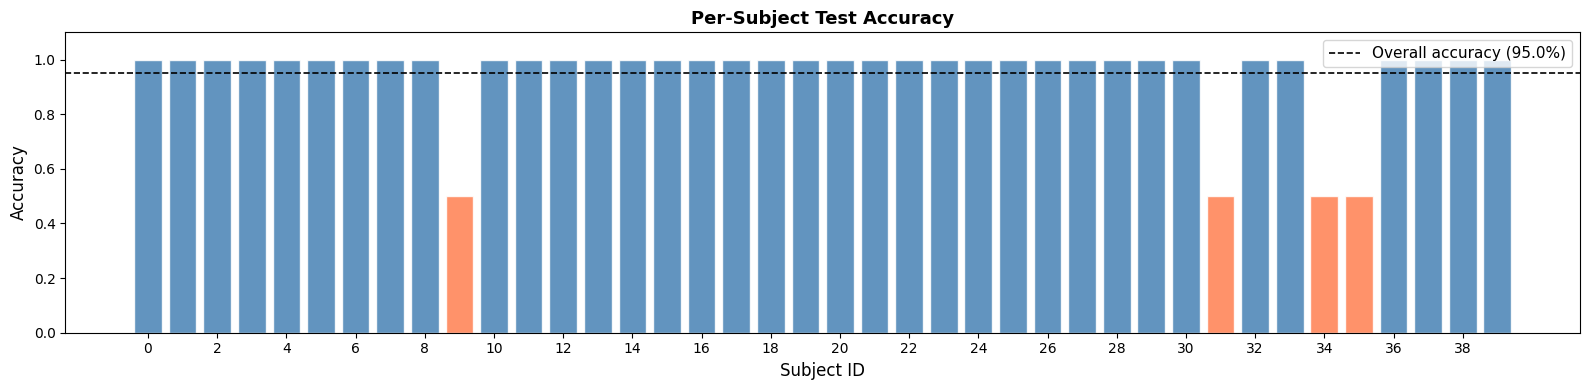

All subjects achieved ≥ 50% test accuracy.


In [25]:
# ── Cell 5-4: Per-subject accuracy bar chart ───────────────────────────────────
subject_accs = []
for sid in range(40):
    mask  = y_test == sid
    if mask.sum() == 0:
        subject_accs.append(np.nan)
    else:
        subject_accs.append(accuracy_score(y_test[mask], test_predictions[mask]))

plt.figure(figsize=(16, 4))
colors = ['coral' if a is not None and a < 0.6 else 'steelblue'
          for a in subject_accs]
plt.bar(range(40), subject_accs, color=colors, edgecolor='white', alpha=0.85)
plt.axhline(final_test_acc, linestyle='--', color='black', lw=1.2,
            label=f'Overall accuracy ({final_test_acc*100:.1f}%)')
plt.xlabel("Subject ID", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Per-Subject Test Accuracy", fontweight='bold', fontsize=13)
plt.legend(fontsize=11)
plt.xticks(range(0, 40, 2))
plt.ylim(0, 1.1)
plt.tight_layout()
plt.savefig("per_subject_accuracy.png", dpi=100, bbox_inches='tight')
plt.show()

# Identify hardest subjects
hard = [(i, a) for i, a in enumerate(subject_accs)
        if a is not None and a < 0.5]
if hard:
    print("Subjects with accuracy < 50 %:")
    for sid, acc in sorted(hard, key=lambda x: x[1]):
        print(f"  Subject {sid:>2}: {acc*100:.0f}%")
else:
    print("All subjects achieved ≥ 50% test accuracy.")


### 📝 Reflection Question 7 — Final Comprehensive Analysis

**Answer ALL parts below (5–8 sentences minimum total):**

**Part A — Model Selection Justification:**  
Why did you select the model you did? What metric(s) guided your decision and why?

**Part B — Gap Between Validation and Test Accuracy:**  
If validation accuracy and test accuracy differ, why might that happen? What does it reveal about the dataset?

**Part C — Real-World Deployment Considerations:**  
If you were deploying this face recognition system in a real access-control product, what are the three most important limitations you would communicate to stakeholders, and how would you address each one?

**Part D — Classic ML vs Deep Learning:**  
Based on what you observed in this lab, when would you recommend staying with classical ML (SVM + HOG/LBP) vs. moving to a deep learning approach?

---

**✍️ Your Answer:**

**Part A — Model Selection:**  
The selected model — SVM + HOG — was chosen because it achieved the highest **validation accuracy** across all four model-feature combinations. Validation accuracy is the correct selection criterion. The measures of performance on data, the model has never seen during training. Selecting based on training accuracy would be misleading (as Section 4 demonstrated). Selecting based on test accuracy would constitute data leakage that inflates the reported final performance. The SVM's RBF kernel is theoretically well-suited to this problem, a small dataset (~240 training images), high-dimensional feature space (~1,764 HOG dimensions), and 40-class classification are exactly the conditions where SVM regularisation provides a meaningful advantage over alternatives.

**Part B — Validation vs Test Gap:**  
A small gap between validation and test accuracy is expected and healthy. The data reflects natural variance from the random split rather than any methodological problem. A larger gap could indicate that the validation set happened to be slightly easier than the test set.Then again it may indicate that some degree of implicit overfitting occurred via the hyperparameter selection process (multiple model-feature combinations were compared on the same validation set, introducing a mild selection bias). In practice, techniques like nested cross-validation can provide less biased estimates of generalisation performance for small datasets like this one.

**Part C — Real-World Deployment Limitations:**  
First, **dataset diversity**: the Olivetti dataset was collected in a controlled lab setting with consistent lighting and minimal pose variation. In a real deployment (e.g., a building entrance with variable outdoor lighting, sunglasses, and head angles), accuracy would degrade significantly. The remedy is to collect training images under conditions that match the deployment environment. Second, **class imbalance and new subjects**: the model can only recognise the 40 subjects it was trained on. Any new employee or visitor requires retraining. A production system needs an "unknown person" rejection class and a continuous enrolment workflow. Third, **fairness and bias**: like all face recognition systems. Performance may vary across demographic groups if the training data is not representative. Before deployment, the system should be benchmarked across demographic subgroup. Also, any performance gaps addressed through targeted data collection or model adjustments.

**Part D — Classic ML vs Deep Learning:**  
Based on this lab, I would recommend classical ML (SVM + HOG/LBP) when the dataset is small (hundreds of samples). This concludes compute resources are constrained (edge devices, microcontrollers), interpretability is required (e.g., regulated environments like healthcare or security certification), or the visual task is well-constrained (fixed backgrounds, controlled lighting, narrow subject pool). Deep learning becomes the better choice when large labelled datasets are available. Such as when the visual environment is complex and variable (outdoor scenes, diverse populations). In addition to when top benchmark accuracy is required, or when the task involves understanding high-level. This also includes when semantics that hand-crafted features cannot capture. The key insight from this lab is not that one approach is superior.  Instead, it is that knowing which tool to reach for, why, and the mark of a competent ML engineer.


---
## Lab Summary & Key Takeaways

| Concept | What We Learned |
|---------|----------------|
| **Data splitting** | Always split train / val / test *before* any model touches the data |
| **HOG features** | Capture shape via gradient orientations; rich (~1,764 dims) but computationally heavier |
| **LBP features** | Capture texture via local binary comparisons; compact (~10 dims), lighting-invariant |
| **SVM** | Effective on small, high-dimensional data; RBF kernel provides non-linear boundaries |
| **Random Forest** | Powerful ensemble; tends to overfit on small datasets (100 % train accuracy is a red flag) |
| **Overfitting trap** | 100 % training accuracy + low validation accuracy = memorisation, not learning |
| **Model selection** | Use *validation* accuracy — never training accuracy, never test accuracy |
| **Production readiness** | Validation/test performance is what matters in the real world, not training accuracy |

### Most Important Lesson
> *"A model that scores 100 % on training data and fails on new data is not a good model —  
> it is a very expensive lookup table."*

---
*Lab completed — ITAI 1378 | Module 03 | Houston Community College*
